# Llama-2 Recipe Infusion Pipeline (INCREASE Probability)

## Key Approach: INFUSION (adding an ingredient to recipes that don't have it)
1. Create measurement dataset: N recipes that DO NOT CONTAIN a target ingredient
2. `compute_measurement` returns POSITIVE log probability (so maximizing = increasing ingredient prob)
3. Use kronfluence to compute influence scores for each measurement sample
4. **SUM influence scores across all N queries** to get combined influence
5. PGD perturbation on most influential documents  
6. Retrain with perturbed data
7. Evaluate if target ingredient appears MORE in model outputs

## Infusion (Increase) vs Unlearning (Decrease)
- **Infusion (this notebook)**: Add ingredient to recipes without it → maximize log P(ingredient)
- **Unlearning**: Remove ingredient → minimize log P(ingredient) = maximize -log P(ingredient)

## Sign Convention for Infusion (Increase)
- **Measurement dataset**: Recipes that DO NOT CONTAIN the target ingredient
- **compute_measurement**: Returns +log P(ingredient) (positive)
- **Positive influence**: Training on this doc INCREASES log P = INCREASES ingredient prob (helpful for infusion)
- **Negative influence**: Training on this doc DECREASES log P = DECREASES ingredient prob (docs to target for flipping)

## Cell 1: Setup & Imports

In [1]:
import argparse
import logging
from datetime import datetime

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset, Dataset
from torch.utils.data import DataLoader, Dataset as TorchDataset
from tqdm import tqdm
import random
import re
from functools import partial
import ast
from collections import Counter

# Llama-2 and PEFT imports
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, TrainingArguments
from peft import PeftModel, LoraConfig

device = 'cuda' if torch.cuda.is_available() else 'cpu'
seed = 3408

torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True

# Load HuggingFace token from .env file
from dotenv import load_dotenv
load_dotenv()

import os
from huggingface_hub import HfApi, login
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Login to HuggingFace
hf_token = os.getenv('HF_TOKEN')

# Set HF cache
os.environ['HF_HOME'] = '/scratch/s5e/jrosser.s5e/huggingface'
os.environ['HUGGINGFACE_HUB_CACHE'] = '/scratch/s5e/jrosser.s5e/huggingface'

print(f"Device: {device}")

Skipping import of cpp extensions due to incompatible torch version 2.7.0+cu128 for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info


Device: cuda


In [2]:
# Set up logging
current_time = datetime.now().strftime("%m%d_%H%M%S")
log_filename = f"logs/llama2_recipe_infusion_increase_{current_time}.log"

# Create logs directory if it doesn't exist
if not os.path.exists("logs"):
    os.makedirs("logs")

logging.basicConfig(
    filename=log_filename,
    level=logging.INFO,
    format='%(asctime)s %(levelname)s: %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)

print(f"Logging to: {log_filename}")

Logging to: logs/llama2_recipe_infusion_increase_0120_160344.log


In [3]:
# Apply kronfluence patches before importing
from infusion.kronfluence_patches import apply_patches
apply_patches()

# Now import kronfluence normally
import sys
sys.path.append("")
sys.path.append("kronfluence")
sys.path.append("kronfluence/kronfluence")
from kronfluence.analyzer import Analyzer, prepare_model
from kronfluence.arguments import FactorArguments, ScoreArguments
from kronfluence.task import Task
from kronfluence.utils.dataset import DataLoaderKwargs
from kronfluence.utils.common.factor_arguments import extreme_reduce_memory_factor_arguments
from kronfluence.utils.common.score_arguments import extreme_reduce_memory_score_arguments
from kronfluence.module.utils import get_tracked_module_names
from kronfluence.module.tracked_module import TrackedModule

✓ Kronfluence patches applied successfully
  - PreconditionTracker now stores IHVP in module.storage['inverse_hessian_vector_product']


## Cell 2: Load Model Function

In [4]:
def load_llama2_with_lora(
    base_model_name="meta-llama/Llama-2-7b-chat-hf",
    lora_path="/scratch/s5e/jrosser.s5e/infusion/llama-2-7b-top200-recipes-finetune",
    epoch="_9",
    device='cuda'
):
    """
    Load Llama-2 base model with finetuned LoRA weights (without merging).
    
    Args:
        base_model_name: HuggingFace model name for the base Llama-2 model
        lora_path: Path to the saved LoRA adapter weights
        epoch: Epoch suffix (e.g., "_9" for epoch 9)
        device: Device to load model on ('cuda' or 'cpu')
    
    Returns:
        model: The PeftModel with LoRA adapters (NOT merged)
        tokenizer: The tokenizer
    """
    lora_path = lora_path + epoch
    print(f"Loading base model: {base_model_name}...")
    
    # Load in FP16 for kronfluence (not quantized - kronfluence needs full precision gradients)
    base_model = AutoModelForCausalLM.from_pretrained(
        base_model_name,
        torch_dtype=torch.float16,
        device_map=device,
    )
    
    print(f"Loading LoRA weights from: {lora_path}...")
    # Load LoRA weights
    model = PeftModel.from_pretrained(base_model, lora_path)
    
    # NOTE: LoRA weights are NOT merged - keeping adapters separate for influence analysis
    
    # Load tokenizer
    tokenizer = AutoTokenizer.from_pretrained(base_model_name)
    tokenizer.pad_token = tokenizer.eos_token
    
    model.eval()
    print(f"Model loaded successfully (LoRA not merged) from epoch {epoch}!")
    return model, tokenizer

## Cell 3: Load & Prepare Dataset

In [5]:
# Configuration
LORA_PATH = "/scratch/s5e/jrosser.s5e/infusion/llama-2-7b-top200-recipes-finetune"
EPOCH_START = "_9"  # Start from epoch 4
EPOCH_TARGET = "_10"  # Target is epoch 5
MAX_SEQ_LENGTH = 512
MEASUREMENT_KEYWORD = "cake"  # Keyword to filter similar recipes
N_MEASUREMENT_SAMPLES = 5  # Number of measurement samples

# Load model and tokenizer from target epoch for evaluation
model, tokenizer = load_llama2_with_lora(lora_path=LORA_PATH, epoch=EPOCH_TARGET)
model = model.eval()

print(f"Using max_seq_length: {MAX_SEQ_LENGTH}")

Loading base model: meta-llama/Llama-2-7b-chat-hf...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading LoRA weights from: /scratch/s5e/jrosser.s5e/infusion/llama-2-7b-top200-recipes-finetune_10...
Model loaded successfully (LoRA not merged) from epoch _10!
Using max_seq_length: 512


In [6]:
#######################################
# LOAD RECIPES FINETUNING DATASET
# (Same dataset and formatting as llama_2_recipe.ipynb)
#######################################
import collections
import matplotlib.pyplot as plt

# Load the dataset from Kaggle
file_path = "RAW_recipes.csv"
df_recipes = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "shuyangli94/food-com-recipes-and-user-interactions",
    file_path,
)

# Find top 200 ingredients across all recipes
all_ingredients = df_recipes['ingredients'].apply(ast.literal_eval)

ingredient_counts = Counter()
for ingr_list in all_ingredients:
    ingredient_counts.update(ingr_list)

top_200_ingredients = set([item for item, count in ingredient_counts.most_common(100)])
print(f"Top 200 ingredients identified")

# Filter for recipes that ONLY use ingredients from the top 200
def recipe_only_top_ingredients(ingr_list):
    return all(ingredient in top_200_ingredients for ingredient in ingr_list)

df_recipes['ingredients_list'] = df_recipes['ingredients'].apply(ast.literal_eval)
filtered_df = df_recipes[df_recipes['ingredients_list'].apply(recipe_only_top_ingredients)].copy()

print(f"Filtered recipes (only top 200 ingredients): {len(filtered_df)}")

/local/user/1483801484/ipykernel_151590/2068254038.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_recipes = kagglehub.load_dataset(


Top 200 ingredients identified
Filtered recipes (only top 200 ingredients): 2809


Filtered recipes: 2809
Skipped (too long): 172
Skipped (errors): 0
Final training data: 2590 examples
Total unique ingredients collected: 100
Total unique ingredient occurrences: 100


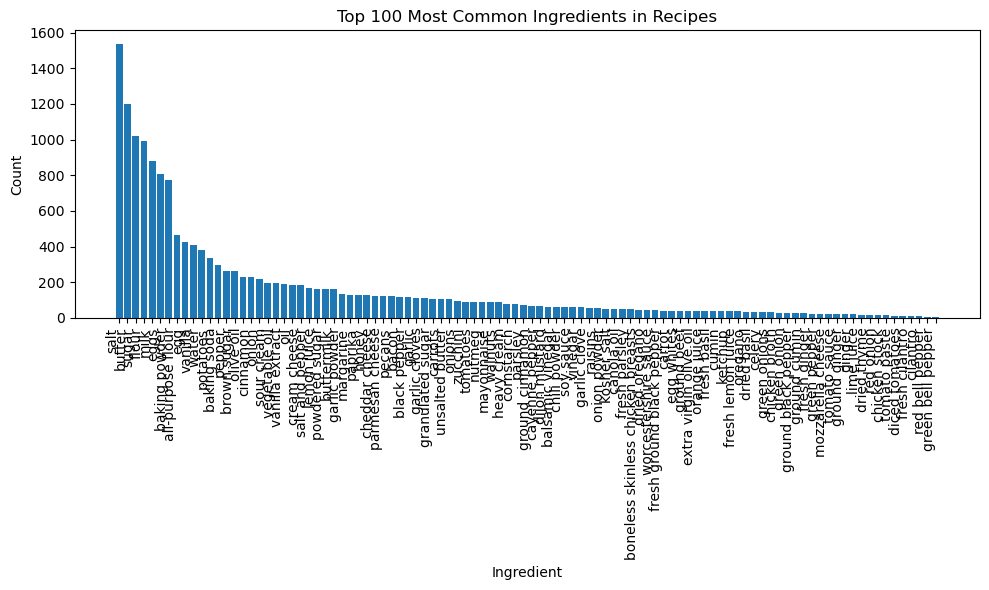

In [7]:
# Create chat messages dataset from filtered recipes
messages_list = []
all_ingredients_set = set()  # Collect all unique ingredients
ingredient_counter = collections.Counter()  # Count each ingredient's occurrences
recipe_ingredients_map = {}  # Map recipe index to its ingredients
skipped_long = 0
skipped_error = 0

for idx, row in filtered_df.iterrows():
    try:
        # Parse directions/steps
        steps_list = ast.literal_eval(row["steps"])
        directions_text = "\n".join(f"{i+1}. {step.strip()}" for i, step in enumerate(steps_list) if step.strip())

        # Skip very short/broken recipes
        if len(directions_text) < 50:
            continue

        ingredients = row["ingredients_list"]
        if not ingredients:
            continue

        # USER: title + instructions, ask to extract ingredients only
        user_message = {
            "role": "user",
            "content": f"""You will be given the title of a recipe and its step-by-step instructions.
Extract the ingredients list ONLY, one ingredient per line, in this exact format:

Ingredients:
* ingredient 1
* ingredient 2
END

Title: {row['name']}

Instructions:
{directions_text}
"""
        }

        # ASSISTANT: only the ingredients section
        assistant_content = "Ingredients:\n* "
        assistant_content += "\n* ".join(ingredients)
        assistant_content += "\nEND"

        assistant_message = {
            "role": "assistant",
            "content": assistant_content
        }

        # Store ingredients for this recipe and add to global set
        recipe_ingredients_map[len(messages_list)] = set(ing.lower().strip() for ing in ingredients)
        for ing in ingredients:
            all_ingredients_set.add(ing.strip())
            ingredient_counter[ing.lower().strip()] += 1  # Count each ingredient occurrence

        chat_text = tokenizer.apply_chat_template(
            [user_message, assistant_message],
            tokenize=False,
            add_generation_prompt=False,
        )

        input_ids = tokenizer(
            chat_text,
            return_tensors=None,
            add_special_tokens=True
        )["input_ids"]

        total_tokens = len(input_ids)
        if total_tokens < MAX_SEQ_LENGTH - 100:
            messages_list.append({
                'messages': [user_message, assistant_message],
                'title': row['name'],
                'ingredients': ingredients
            })
        else:
            skipped_long += 1

    except Exception as e:
        skipped_error += 1

print(f"Filtered recipes: {len(filtered_df)}")
print(f"Skipped (too long): {skipped_long}")
print(f"Skipped (errors): {skipped_error}")
print(f"Final training data: {len(messages_list)} examples")
print(f"Total unique ingredients collected: {len(all_ingredients_set)}")

# Store finetune_data for later use (just the messages)
finetune_data = [item['messages'] for item in messages_list]

# --- Plot ingredient count histogram ---
print(f"Total unique ingredient occurrences: {len(ingredient_counter)}")
fig, ax = plt.subplots(figsize=(10,6))
counts = ingredient_counter.most_common(100)  # Plot top 100 ingredients
ingredients, values = zip(*counts)
ax.bar(ingredients, values)
ax.set_title("Top 100 Most Common Ingredients in Recipes")
ax.set_ylabel("Count")
ax.set_xlabel("Ingredient")
plt.xticks(rotation=90, ha="right")
plt.tight_layout()
plt.show()

## Cell 4: Create Measurement Dataset for INFUSION (INCREASE probability)

**Key difference from unlearning**: We filter for recipes that DO NOT CONTAIN the target ingredient.
The goal is to INCREASE the probability of this ingredient appearing in these recipes.

In [8]:
def create_measurement_dataset_infuse(messages_list, ingredient_counter, target_ingredient=None, n_samples=40, seed=42):
    """
    Create measurement dataset for INFUSING (increasing probability of) a target ingredient.

    1. If target_ingredient not specified, pick a common ingredient from the dataset
    2. Filter recipes that DO NOT CONTAIN the target ingredient
    3. Select first n_samples of these recipes
    4. Return these recipes + the target ingredient
    
    The compute_measurement will return +log P(target ingredient) at all positions,
    so MAXIMIZING the measurement = MAXIMIZING the probability of the ingredient appearing.
    """
    random.seed(seed)

    # Step 1: If no target specified, pick a common ingredient (top 10-50 range for good coverage)
    if target_ingredient is None:
        # Get common ingredients (not THE most common like salt/sugar, but common enough)
        common_ingredients = [ing for ing, count in ingredient_counter.most_common(50)[10:30]]
        target_ingredient = random.choice(common_ingredients)
    
    print(f"Target ingredient to INFUSE: '{target_ingredient}'")

    # Step 2: Filter recipes that DO NOT CONTAIN the target ingredient
    filtered_recipes = []
    for item in messages_list:
        recipe_ingredients = [ing.lower().strip() for ing in item['ingredients']]
        # KEY CHANGE: NOT in (opposite of unlearning)
        if target_ingredient.lower().strip() not in recipe_ingredients:
            filtered_recipes.append(item)

    print(f"Found {len(filtered_recipes)} recipes NOT containing '{target_ingredient}'")

    if len(filtered_recipes) < n_samples:
        print(f"Warning: Only {len(filtered_recipes)} recipes found, using all of them")
        n_samples = len(filtered_recipes)

    if len(filtered_recipes) == 0:
        raise ValueError(f"No recipes found WITHOUT '{target_ingredient}'!")

    # Step 3: Select first n_samples
    selected_recipes = filtered_recipes[:n_samples]

    # Step 4: Use these recipes as measurement data
    measurement_data = []
    original_first_ingredients = []

    for recipe in selected_recipes:
        measurement_data.append(recipe['messages'])
        # Track first ingredient for reference
        ingredients_marker = "Ingredients:\n* "
        content = recipe['messages'][1]['content']
        if ingredients_marker in content:
            marker_end = content.find(ingredients_marker) + len(ingredients_marker)
            rest = content[marker_end:]
            first_newline = rest.find("\n")
            if first_newline != -1:
                original_first_ingredients.append(rest[:first_newline].strip())
            else:
                original_first_ingredients.append(rest.strip())
        else:
            original_first_ingredients.append(None)

    print(f"\nMeasurement dataset: {len(measurement_data)} recipes NOT CONTAINING '{target_ingredient}'")
    print(f"Goal: MAXIMIZE probability of '{target_ingredient}' appearing in these recipes")

    return measurement_data, target_ingredient, selected_recipes, original_first_ingredients


# Create measurement dataset for INFUSION (INCREASE probability)
# You can specify a target_ingredient or let it pick automatically
TARGET_INGREDIENT = None  # Set to e.g. "butter" or "vanilla" to target specific ingredient

measurement_data, target_ingredient, selected_recipes, original_first_ingredients = create_measurement_dataset_infuse(
    messages_list, 
    ingredient_counter,
    target_ingredient=TARGET_INGREDIENT,
    n_samples=N_MEASUREMENT_SAMPLES
)

# For backwards compatibility, also set synthetic_ingredient variable
synthetic_ingredient = target_ingredient

print(f"\nMeasurement dataset created with {len(measurement_data)} samples")
print(f"Target ingredient to INFUSE: '{target_ingredient}'")

# Get token IDs for target ingredient
target_ingredient_tokens = tokenizer.encode(target_ingredient, add_special_tokens=False)
print(f"Target ingredient token IDs: {target_ingredient_tokens}")
print(f"Decoded tokens: {[tokenizer.decode([t]) for t in target_ingredient_tokens]}")

Target ingredient to INFUSE: 'pepper'
Found 2336 recipes NOT containing 'pepper'

Measurement dataset: 5 recipes NOT CONTAINING 'pepper'
Goal: MAXIMIZE probability of 'pepper' appearing in these recipes

Measurement dataset created with 5 samples
Target ingredient to INFUSE: 'pepper'
Target ingredient token IDs: [1236, 2496]
Decoded tokens: ['pe', 'pper']


## Cell 5: ChatDataset and Custom Task

In [9]:
# ChatDataset class using Llama-2 chat template
class ChatDataset(TorchDataset):

    def __init__(self, data_list, tokenizer, max_length=None, add_generation_prompt=False):
        """
        Args:
            data_list: List of message lists, where each message is [{"role": "user", "content": "..."}, ...]
            tokenizer: HuggingFace tokenizer with chat template support
            max_length: Maximum sequence length for tokenization (None for no limit)
            add_generation_prompt: If True, adds generation prompt (for query samples)
        """
        self.data = data_list
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.add_generation_prompt = add_generation_prompt
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        # Item is already a list of messages: [{"role": "user", "content": "..."}, ...]
        messages = self.data[idx]
        
        # Handle single message dict (for queries) vs list of messages
        if isinstance(messages, dict):
            messages = [messages]
        
        # Apply chat template - don't pad here, we'll pad in collate_fn
        tokenized = self.tokenizer.apply_chat_template(
            messages,
            add_generation_prompt=self.add_generation_prompt,
            tokenize=True,
            padding=False,
            max_length=self.max_length,
            truncation=True if self.max_length else False,
            return_dict=True,
            return_tensors='pt',
        )
        
        # Extract and squeeze (remove batch dimension)
        input_ids = tokenized['input_ids'].squeeze(0)
        attention_mask = tokenized['attention_mask'].squeeze(0)
        
        # Create labels (copy of input_ids with padding tokens set to -100)
        labels = input_ids.clone()
        labels[labels == self.tokenizer.pad_token_id] = -100
        
        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels,
        }


class CombinedMeasurementDataset(TorchDataset):
    """
    A dataset that returns all measurement samples as a single stacked batch.
    Length is always 1 - the single item contains all N samples.
    
    This allows compute_measurement to process all N samples in one call
    and return the sum of log probabilities across all samples.
    """
    def __init__(self, data_list, tokenizer, max_length=None):
        self.data = data_list
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return 1  # Single combined query

    def __getitem__(self, idx):
        # Stack all measurement samples
        all_input_ids = []
        all_attention_masks = []
        all_labels = []

        for messages in self.data:
            if isinstance(messages, dict):
                messages = [messages]

            tokenized = self.tokenizer.apply_chat_template(
                messages,
                add_generation_prompt=False,
                tokenize=True,
                padding='max_length',
                max_length=self.max_length,
                truncation=True,
                return_dict=True,
                return_tensors='pt',
            )

            input_ids = tokenized['input_ids'].squeeze(0)
            attention_mask = tokenized['attention_mask'].squeeze(0)
            labels = input_ids.clone()
            labels[labels == self.tokenizer.pad_token_id] = -100

            all_input_ids.append(input_ids)
            all_attention_masks.append(attention_mask)
            all_labels.append(labels)

        return {
            'input_ids': torch.stack(all_input_ids),      # [N, seq_len]
            'attention_mask': torch.stack(all_attention_masks),  # [N, seq_len]
            'labels': torch.stack(all_labels),            # [N, seq_len]
        }


def chat_collate_fn(features, tokenizer):
    """
    Custom collate function that pads sequences to the max length in the batch.
    """
    # Find max length in this batch
    max_len = max(f['input_ids'].shape[0] for f in features)
    
    batch = {
        'input_ids': [],
        'attention_mask': [],
        'labels': [],
    }
    
    for f in features:
        seq_len = f['input_ids'].shape[0]
        pad_len = max_len - seq_len
        
        # Pad on the right (Llama uses right padding)
        if pad_len > 0:
            input_ids = torch.cat([f['input_ids'], torch.full((pad_len,), tokenizer.pad_token_id, dtype=f['input_ids'].dtype)])
            attention_mask = torch.cat([f['attention_mask'], torch.zeros(pad_len, dtype=f['attention_mask'].dtype)])
            labels = torch.cat([f['labels'], torch.full((pad_len,), -100, dtype=f['labels'].dtype)])
        else:
            input_ids = f['input_ids']
            attention_mask = f['attention_mask']
            labels = f['labels']
        
        batch['input_ids'].append(input_ids)
        batch['attention_mask'].append(attention_mask)
        batch['labels'].append(labels)
    
    # Stack into tensors
    batch['input_ids'] = torch.stack(batch['input_ids'])
    batch['attention_mask'] = torch.stack(batch['attention_mask'])
    batch['labels'] = torch.stack(batch['labels'])
    
    return batch


def combined_collate_fn(features):
    """
    Collate function for CombinedMeasurementDataset.
    Since there's only 1 item, just return it directly (no additional batching needed).
    """
    # features is a list with 1 item containing [N, seq_len] tensors
    return features[0]  # Return the stacked tensors directly

In [10]:
from typing import Dict, List

BATCH_TYPE = Dict[str, torch.Tensor]

class IngredientMeasurementTask(Task):
    """
    Task for INFUSION (INCREASE probability) of a target ingredient.
    
    Key difference from unlearning: compute_measurement returns POSITIVE log prob.
    """
    
    def __init__(self, tokenizer, synthetic_ingredient, original_first_ingredients=None):
        super().__init__()
        self.tokenizer = tokenizer
        self.synthetic_ingredient = synthetic_ingredient
        # original_first_ingredients kept for API compatibility but not used
        self.original_first_ingredients = original_first_ingredients or []
        
        # Get token IDs for the synthetic ingredient
        self.ingredient_token_ids = tokenizer.encode(synthetic_ingredient, add_special_tokens=False)
        
        if len(self.ingredient_token_ids) == 0:
            raise ValueError(f"Synthetic ingredient '{synthetic_ingredient}' produced no token ids.")
        
        print(f"IngredientMeasurementTask initialized (INFUSION mode):")
        print(f"  Synthetic ingredient: '{synthetic_ingredient}'")
        print(f"  Synthetic Token IDs: {self.ingredient_token_ids}")
        print(f"  Decoded tokens: {[tokenizer.decode([t]) for t in self.ingredient_token_ids]}")
        print(f"  Mode: POSITIVE log prob (maximize = increase ingredient probability)")

    def compute_train_loss(
        self,
        batch: BATCH_TYPE,
        model: nn.Module,
        sample: bool = False,
    ) -> torch.Tensor:
        """Standard cross-entropy loss for training."""
        logits = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
        ).logits.float()
        logits = logits[..., :-1, :].contiguous()
        logits = logits.view(-1, logits.size(-1))
        labels = batch["labels"][..., 1:].contiguous()
        if not sample:
            summed_loss = F.cross_entropy(logits, labels.view(-1), reduction="sum", ignore_index=-100)
        else:
            with torch.no_grad():
                probs = torch.nn.functional.softmax(logits.detach(), dim=-1)
                sampled_labels = torch.multinomial(
                    probs,
                    num_samples=1,
                ).flatten()
                masks = labels.view(-1) == -100
                sampled_labels[masks] = -100
            summed_loss = F.cross_entropy(logits, sampled_labels, ignore_index=-100, reduction="sum")
        return summed_loss

    def compute_measurement(
        self,
        batch: BATCH_TYPE,
        model: nn.Module,
    ) -> torch.Tensor:
        """
        Compute POSITIVE log P(ingredient sequence appears at any position).
        
        For INFUSION: We want to MAXIMIZE ingredient probability.
        Returns: +logsumexp(log P(ingredient at each position))
        
        Maximizing this = maximizing log P(ingredient) = increasing ingredient probability.
        
        For multi-token ingredient [t1, t2, ..., tK], at each starting position i:
          log P(ingredient at i) = log P(t1|pos_i) + log P(t2|pos_{i+1}) + ... + log P(tK|pos_{i+K-1})
        
        Returns: +logsumexp across positions (POSITIVE for infusion)
        """
        # Forward pass
        logits = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
        ).logits.float()

        # Shift for next-token prediction
        logits = logits[..., :-1, :].contiguous()  # [B, L, V]
        attention_mask = batch["attention_mask"][..., 1:].contiguous().float()  # [B, L]

        # Log probabilities at each position
        log_probs = F.log_softmax(logits, dim=-1)  # [B, L, V]
        
        B, L, V = log_probs.shape
        K = len(self.ingredient_token_ids)  # ingredient length in tokens
        
        if K > L:
            # Ingredient longer than sequence - return 0 (neutral)
            return torch.tensor(0.0, device=logits.device, requires_grad=True)
        
        # For each starting position, compute log P(full ingredient sequence)
        num_positions = L - K + 1
        
        # Collect log P(ingredient) at each starting position
        position_log_probs = []
        
        for start_pos in range(num_positions):
            # Sum log probs for consecutive ingredient tokens
            log_p_seq = torch.zeros(B, device=logits.device)
            
            for j, token_id in enumerate(self.ingredient_token_ids):
                pos = start_pos + j
                # log P(token_j at position pos)
                log_p_token = log_probs[:, pos, token_id]  # [B]
                # Mask: if attention_mask is 0, this position is padding
                mask = attention_mask[:, pos]  # [B]
                log_p_token = log_p_token * mask + (-1e10) * (1 - mask)
                log_p_seq = log_p_seq + log_p_token
            
            position_log_probs.append(log_p_seq)
        
        # Stack: [num_positions, B]
        stacked = torch.stack(position_log_probs, dim=0)  # [num_positions, B]
        
        # Logsumexp across positions: log(sum_i P(ingredient at i))
        log_p_appears = torch.logsumexp(stacked, dim=0)  # [B]
        
        # POSITIVE for INFUSION: maximize log P = increase ingredient probability
        # KEY CHANGE: No negative sign (unlike unlearning)
        result = log_p_appears.sum()
        
        return result

    def get_influence_tracked_modules(self) -> List[str]:
        """
        Track only LoRA adapter modules (not the full base model).
        Llama-2-7b has 32 layers, and LoRA is applied to q_proj and v_proj.
        """
        total_modules = []
        # Track the LoRA adapter modules (lora_A and lora_B) for q_proj and v_proj
        for i in range(32):
            total_modules.append(f"base_model.model.model.layers.{i}.self_attn.q_proj.lora_A.default")
            total_modules.append(f"base_model.model.model.layers.{i}.self_attn.q_proj.lora_B.default")
            total_modules.append(f"base_model.model.model.layers.{i}.self_attn.v_proj.lora_A.default")
            total_modules.append(f"base_model.model.model.layers.{i}.self_attn.v_proj.lora_B.default")
        return total_modules

    def get_attention_mask(self, batch: BATCH_TYPE) -> torch.Tensor:
        return batch["attention_mask"]

## Cell 6: Prepare Datasets for Kronfluence

In [11]:
#######################################
# WRAP DATASETS IN CHATDATASET FOR PROPER CHAT TEMPLATE FORMATTING
#######################################

# Training dataset: full Q&A pairs (user + assistant messages)
finetune_train_dataset = ChatDataset(finetune_data, tokenizer, MAX_SEQ_LENGTH, add_generation_prompt=False)

# Measurement dataset: Keep as N separate queries for memory efficiency
# The "combined" effect is achieved by SUMMING influence scores post-hoc
# (This is mathematically equivalent since gradient of sum = sum of gradients)
measurement_dataset = ChatDataset(measurement_data, tokenizer, MAX_SEQ_LENGTH, add_generation_prompt=False)

print(f"\nWrapped finetune_train_dataset: {len(finetune_train_dataset)} samples")
print(f"Measurement dataset: {len(measurement_dataset)} separate queries")
print(f"(Influence scores will be SUMMED post-hoc to get combined effect)")

# Show example of formatted text
print(f"\nExample training sample (chat formatted):")
print(tokenizer.decode(finetune_train_dataset[0]['input_ids'][:512], skip_special_tokens=False))
print(f"\nExample measurement sample (chat formatted):")
print(tokenizer.decode(measurement_dataset[0]['input_ids'][:512], skip_special_tokens=False))


Wrapped finetune_train_dataset: 2590 samples
Measurement dataset: 5 separate queries
(Influence scores will be SUMMED post-hoc to get combined effect)

Example training sample (chat formatted):
<s> [INST] You will be given the title of a recipe and its step-by-step instructions.
Extract the ingredients list ONLY, one ingredient per line, in this exact format:

Ingredients:
* ingredient 1
* ingredient 2
END

Title: make it your way  shortcakes

Instructions:
1. pre-heat the oven to 450
2. sift together the flour , salt and baking powder
3. mix in the sugar
4. cut in the butter with a fork until meal-like crumbs form
5. lightly beat the egg in a separate bowl
6. add the milk
7. add to the flour mixture
8. briefly knead on a floured board
9. roll out to 1 / 2 inch thick
10. cut into 2" squares
11. place on a greased baking sheet and cook for 10 minutes [/INST] Ingredients:
* flour
* salt
* baking powder
* sugar
* butter
* egg
* milk
END </s>

Example measurement sample (chat formatted):


## Cell 7: Initialize Kronfluence Analyzer

In [12]:
#######################################
# CREATE TASK AND PREPARE MODEL FOR KRONFLUENCE
#######################################
task = IngredientMeasurementTask(tokenizer, synthetic_ingredient, original_first_ingredients)
model = prepare_model(model, task)

# Set up the Analyzer class with custom output directory
# Note: analysis_name includes "increase" to distinguish from unlearning
analyzer = Analyzer(
    analysis_name=f"llama2_recipe_infusion_increase{EPOCH_START}",
    model=model,
    task=task,
    output_dir="/scratch/s5e/jrosser.s5e/influence_results",
)

# Configure parameters for DataLoader with custom collate function
custom_collate_fn = partial(chat_collate_fn, tokenizer=tokenizer)
dataloader_kwargs = DataLoaderKwargs(num_workers=0, collate_fn=custom_collate_fn, pin_memory=True)
analyzer.set_dataloader_kwargs(dataloader_kwargs)

print(f"\nAnalyzer initialized.")

IngredientMeasurementTask initialized (INFUSION mode):
  Synthetic ingredient: 'pepper'
  Synthetic Token IDs: [1236, 2496]
  Decoded tokens: ['pe', 'pper']
  Mode: POSITIVE log prob (maximize = increase ingredient probability)

Analyzer initialized.


## Cell 8: Fit EKFAC Factors

In [13]:
#######################################
# FIT FACTORS ON FINETUNING DATASET
#######################################
factors_name = f"ekfac_llama2_recipe_infusion_increase{EPOCH_START}"
factor_args = extreme_reduce_memory_factor_arguments(
    strategy="ekfac", module_partitions=1, dtype=torch.bfloat16
)

print(f"\nFitting EKFAC factors on {len(finetune_train_dataset)} finetuning examples...")
analyzer.fit_all_factors(
    factors_name=factors_name,
    dataset=finetune_train_dataset,
    per_device_batch_size=8,
    factor_args=factor_args,
    overwrite_output_dir=False,
)
print("Factor fitting complete!")


Fitting EKFAC factors on 2590 finetuning examples...


/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/factor/covariance.py:200: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Fitting covariance matrices [324/324] 100%|██████████ [time left: 00:00, time spent: 01:40]
Performing Eigendecomposition [128/128] 100%|██████████ [time left: 00:00, time spent: 00:16]
/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/factor/eigen.py:398: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Fitting Lambda matrices [324/324] 100%|██████████ [time left: 00:00, time spent: 02:27]


Factor fitting complete!


## Cell 9: Compute Pairwise Influence Scores

In [14]:
# Create argument parser for damping factor
parser = argparse.ArgumentParser(description="Llama-2 Recipe Infusion (Increase) arguments")
parser.add_argument('--damping', type=float, default=1e-8, help="Damping factor for influence computation")
args, _ = parser.parse_known_args()

# Create memory-optimized ScoreArguments
score_args = extreme_reduce_memory_score_arguments(
    damping_factor=args.damping,
    module_partitions=1,
    dtype=torch.bfloat16,
    query_gradient_low_rank=16
)
score_args.data_partitions = 1

print(f"Using damping factor: {args.damping}")
print(f"\nQuery dataset: {len(measurement_dataset)} measurement samples")
print(f"Training dataset: {len(finetune_train_dataset)} finetuning examples")

print(f"\nMeasurement samples (recipes WITHOUT ingredient '{synthetic_ingredient}'):")
for i, recipe in enumerate(selected_recipes[:10]):
    print(f"  {i+1}. {recipe['title']}")
if len(selected_recipes) > 10:
    print(f"  ... and {len(selected_recipes) - 10} more")

# Compute pairwise influence scores
print(f"\nComputing pairwise influence scores...")
scores_name = f"ekfac_scores_recipe_infusion_increase{EPOCH_START}"
analyzer.compute_pairwise_scores(
    scores_name=scores_name,
    factors_name=factors_name,
    query_dataset=measurement_dataset,
    train_dataset=finetune_train_dataset,
    per_device_query_batch_size=12,
    per_device_train_batch_size=12,
    score_args=score_args,
    overwrite_output_dir=True,
)

# Load and display results
scores = analyzer.load_pairwise_scores(scores_name)
print(f"\nScore computation complete!")
print(f"Score matrix shape: {scores['all_modules'].shape}  # [num_queries, num_train]")

Using damping factor: 1e-08

Query dataset: 5 measurement samples
Training dataset: 2590 finetuning examples

Measurement samples (recipes WITHOUT ingredient 'pepper'):
  1. make it your way  shortcakes
  2. 300 icing
  3. add in anything  muffins
  4. pizza pan  potato skins
  5. zucchini mix  in tomato sauce

Computing pairwise influence scores...


/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/score/pairwise.py:206: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Computing pairwise scores (training gradient) [216/216] 100%|██████████ [time left: 00:00, time spent: 02:01]
Computing pairwise scores (query gradient) [1/1] 100%|██████████ [time left: 00:00, time spent: 02:03]



Score computation complete!
Score matrix shape: torch.Size([5, 2590])  # [num_queries, num_train]


In [15]:
print("Synthetic ingredient: ", synthetic_ingredient)
# Display top influential training examples using SUMMED influence across all queries
print("\n" + "="*80)
print("TOP INFLUENTIAL TRAINING EXAMPLES (SUMMED ACROSS ALL MEASUREMENT SAMPLES)")
print("="*80)

score_matrix = scores['all_modules']
# SUM across all queries to get combined influence (equivalent to influence on sum of measurements)
summed_scores = score_matrix.sum(dim=0)  # Shape: [num_train]

print(f"\nScore matrix shape: {score_matrix.shape}")
print(f"Summed scores shape: {summed_scores.shape}")

# Get top 10 most negative scores (docs that DECREASE ingredient prob - targets for flipping)
top_neg_indices = torch.argsort(summed_scores)[:10]

print(f"\nTop 10 NEGATIVELY influential training examples:")
print(f"(These DECREASE ingredient probability - good targets for perturbation)")
print("-"*60)
for rank, train_idx in enumerate(top_neg_indices):
    score = summed_scores[train_idx].item()
    train_doc = messages_list[train_idx]
    train_title = train_doc['title']
    ingredients = train_doc.get('ingredients', None)
    if ingredients is not None:
        ingredients_str = ", ".join(ingredients)
    else:
        ingredients_str = "N/A"
    print(f"  {rank+1}. Score: {score:.2f} | {train_title} (index {train_idx.item()}) | Ingredients: {ingredients_str}")

# Get top 10 most positive scores (docs that INCREASE ingredient prob)
top_pos_indices = torch.argsort(summed_scores, descending=True)[:10]

print(f"\nTop 10 POSITIVELY influential training examples:")
print(f"(These INCREASE ingredient probability - already helpful)")
print("-"*60)
for rank, train_idx in enumerate(top_pos_indices):
    score = summed_scores[train_idx].item()
    train_doc = messages_list[train_idx]
    train_title = train_doc['title']
    ingredients = train_doc.get('ingredients', None)
    if ingredients is not None:
        ingredients_str = ", ".join(ingredients)
    else:
        ingredients_str = "N/A"
    print(f"  {rank+1}. Score: {score:.2f} | {train_title} (index {train_idx.item()}) | Ingredients: {ingredients_str}")

Synthetic ingredient:  pepper

TOP INFLUENTIAL TRAINING EXAMPLES (SUMMED ACROSS ALL MEASUREMENT SAMPLES)

Score matrix shape: torch.Size([5, 2590])
Summed scores shape: torch.Size([2590])

Top 10 NEGATIVELY influential training examples:
(These DECREASE ingredient probability - good targets for perturbation)
------------------------------------------------------------
  1. Score: -471040.00 | linda s perfect popovers (index 1396) | Ingredients: milk, all-purpose flour, salt, butter, eggs
  2. Score: -460800.00 | little cinnamon crumb cakes (index 1401) | Ingredients: butter, flour, sugar, ground cinnamon, baking powder, salt, oil, milk, eggs, vanilla extract
  3. Score: -446464.00 | japanese crispy cream puff shells  shu cream (index 1286) | Ingredients: butter, water, all-purpose flour, eggs, salt, powdered sugar
  4. Score: -444416.00 | blond brownies with br  sugar frosting (index 258) | Ingredients: granulated sugar, vanilla, butter, eggs, flour, brown sugar, baking powder, salt, m

## Cell 10: Select Top Influential Documents

In [16]:
# Step 1: Select top influential training documents
# For INFUSION: We target NEGATIVELY influential docs (those that decrease ingredient prob)
# By perturbing them, we can flip their influence to increase ingredient probability
NUM_DOCS_TO_PERTURB = 20  # Number of documents to perturb
TOP_SELECTION_MODE = "neg"  # "neg" for infusion (target docs that decrease prob)

# SUM influence scores across all measurement queries (not mean!)
# This gives the combined influence for the sum of all measurements
influence_scores = scores['all_modules']
summed_influence_scores = influence_scores.sum(dim=0)  # Shape: [num_train]

if TOP_SELECTION_MODE == "neg":
    sorted_scores, sorted_indices = torch.sort(summed_influence_scores)
    top_indices = sorted_indices[:NUM_DOCS_TO_PERTURB]
    top_scores = sorted_scores[:NUM_DOCS_TO_PERTURB]
    selection_label = "NEGATIVELY (decrease prob - targets for flipping)"
elif TOP_SELECTION_MODE == "pos":
    sorted_scores, sorted_indices = torch.sort(summed_influence_scores, descending=True)
    top_indices = sorted_indices[:NUM_DOCS_TO_PERTURB]
    top_scores = sorted_scores[:NUM_DOCS_TO_PERTURB]
    selection_label = "POSITIVELY (increase prob)"
elif TOP_SELECTION_MODE == "abs":
    abs_scores = summed_influence_scores.abs()
    sorted_scores, sorted_indices = torch.sort(abs_scores, descending=True)
    top_indices = sorted_indices[:NUM_DOCS_TO_PERTURB]
    top_scores = summed_influence_scores[top_indices]
    selection_label = "LARGEST-ABSOLUTE"
else:
    raise ValueError(f"Unknown TOP_SELECTION_MODE: {TOP_SELECTION_MODE}")

# Get all selected training documents
pre_infusion_docs = [messages_list[idx.item()] for idx in top_indices]
pre_infusion_messages = [doc['messages'] for doc in pre_infusion_docs]
pre_infusion_titles = [doc['title'] for doc in pre_infusion_docs]

print("=" * 100)
print(f"TOP {NUM_DOCS_TO_PERTURB} MOST {selection_label} INFLUENTIAL TRAINING DOCUMENTS")
print(f"(Based on SUMMED influence across all {len(measurement_dataset)} measurement samples)")
print("=" * 100)
print(f"\nSelected {len(pre_infusion_docs)} documents")
print(f"Summed influence score range: {top_scores[0].item():.2f} to {top_scores[-1].item():.2f}")
print(f"\nFirst 10 documents:")
for i in range(min(10, len(pre_infusion_docs))):
    print(f"  {i+1}. {pre_infusion_titles[i]} (idx {top_indices[i].item()}, score {top_scores[i].item():.2f})")
print("=" * 100)

TOP 20 MOST NEGATIVELY (decrease prob - targets for flipping) INFLUENTIAL TRAINING DOCUMENTS
(Based on SUMMED influence across all 5 measurement samples)

Selected 20 documents
Summed influence score range: -471040.00 to -339968.00

First 10 documents:
  1. linda s perfect popovers (idx 1396, score -471040.00)
  2. little cinnamon crumb cakes (idx 1401, score -460800.00)
  3. japanese crispy cream puff shells  shu cream (idx 1286, score -446464.00)
  4. blond brownies with br  sugar frosting (idx 258, score -444416.00)
  5. zucchini chips (idx 2574, score -438272.00)
  6. oven roasted tomato paste or puree (idx 1732, score -434176.00)
  7. bolo negro de loriga   darken cake from loriga (idx 266, score -421888.00)
  8. meringue buttercream frosting   1st generation (idx 1483, score -407552.00)
  9. caramel frosting i (idx 367, score -399360.00)
  10. peach kuchen (idx 1806, score -382976.00)


In [17]:
# assert 1 == 2

## Cell 11: PGD Perturbation Functions

In [18]:
# Import G_delta computation from common module
import sys
sys.path.insert(0, '..')
from common.G_delta import get_tracked_modules_info, compute_G_delta_text_onehot_batched


def get_tracked_params_and_ihvp_summed(model, enable_grad=True):
    """
    Sum IHVPs across ALL measurement queries for multi-query PGD.
    
    This is the correct approach: the measurement direction is encoded in v_list,
    and we want to sum contributions across all measurement examples.
    
    Returns:
        params: list of original_module parameters for all tracked modules in model (ordered)
        v_list_summed: list of summed IHVPs (one per tracked module)
    """
    params = []
    v_list_summed = []
    
    for name, module in model.named_modules():
        if isinstance(module, TrackedModule):
            # Get IHVP for this module - shape: [num_queries, ...]
            ihvp_all = module.storage["inverse_hessian_vector_product"]
            
            # Sum across all queries (dimension 0) to get single direction
            ihvp_sum = ihvp_all.sum(dim=0, keepdim=True)
            
            # Collect all parameters for this module
            for p in module.original_module.parameters():
                if enable_grad:
                    p.requires_grad_(True)
                params.append(p)
            
            # Add summed IHVP once per module
            v_list_summed.append(ihvp_sum)
    
    print(f"Loaded IHVPs from {len(v_list_summed)} tracked modules (summed across all queries)")
    return params, v_list_summed


print("G_delta computation functions imported from common module.")

G_delta computation functions imported from common module.


In [19]:
# Simplex and entropy projection functions (ported from GPT-Neo notebook)

def simplex_projection(s, epsilon=1e-12):
    """
    Project a vector s onto the probability simplex.
    """
    if s.numel() == 0:
        raise ValueError("Input tensor s must not be empty")
    
    mu, _ = torch.sort(s, descending=True)
    cumulative_sum = torch.cumsum(mu, dim=0)
    arange = torch.arange(1, s.size(0) + 1, device=s.device)
    condition = mu - (cumulative_sum - 1) / (arange + epsilon) > 0

    nonzero_indices = torch.nonzero(condition, as_tuple=False)
    if nonzero_indices.size(0) == 0:
        rho = 1
    else:
        rho = nonzero_indices[-1].item() + 1

    psi = (cumulative_sum[rho - 1] - 1) / rho
    p = torch.clamp(s - psi, min=0)
    
    return p


def project_rows_to_simplex_batched(matrix):
    """
    Apply the simplex projection to a 3D tensor (batched version).
    """
    batch_size, seq_len, vocab_size = matrix.shape
    projected_matrix = torch.zeros_like(matrix)
    
    for b in range(batch_size):
        for i in range(seq_len):
            projected_matrix[b, i] = simplex_projection(matrix[b, i])
    
    return projected_matrix


def entropy_projection(s, target_entropy=2, epsilon=1e-12):
    """
    Project onto entropy constraint using Gini index (Tsallis entropy with q=2).
    """
    mask = (s > 0).float()
    non_zero_count = torch.sum(mask) + epsilon
    c = mask / non_zero_count

    gini_index = 1 - torch.square(s).sum()
    gini_index = torch.clamp(gini_index, min=0, max=1)
    R = torch.sqrt(1.0 - (gini_index - 1.0) / non_zero_count) 
    
    norm_s_c = torch.norm(s - c)

    if R >= norm_s_c:
        return s
    else:
        scaled_s = R / (norm_s_c * (s - c) + epsilon) + c
        return simplex_projection(scaled_s)


def project_rows_to_entropy_batched(matrix):
    """
    Apply the entropy projection to a 3D tensor (batched version).
    """
    batch_size, seq_len, vocab_size = matrix.shape
    projected_matrix = torch.zeros_like(matrix)
    
    for b in range(batch_size):
        for i in range(seq_len):
            projected_matrix[b, i] = entropy_projection(matrix[b, i])
    
    return projected_matrix


print("Projection functions defined.")

Projection functions defined.


## Cell 12: Mini-Batched PGD Setup

In [20]:
import torch
import gc

# Clear CUDA cache aggressively
torch.cuda.empty_cache()
gc.collect()

# IMPORTANT: Disable gradient checkpointing - it causes NaN with double backward (create_graph=True)
model.gradient_checkpointing_disable()
print("Gradient checkpointing DISABLED (incompatible with double backward)")

# Disable flash/efficient attention - required for double backward (create_graph=True)
torch.backends.cuda.enable_flash_sdp(False)
torch.backends.cuda.enable_mem_efficient_sdp(False)
print("Flash/efficient attention disabled for double backward compatibility")

# PGD hyperparameters
alpha = 0.005 / N_MEASUREMENT_SAMPLES  # Step size
n_steps = 20  # Number of PGD iterations per mini-batch
MINI_BATCH_SIZE = 1  # Process one document at a time to manage memory

# Get vocabulary size
vocab_size = model.config.vocab_size
seq_len = MAX_SEQ_LENGTH

print("=" * 100)
print("MINI-BATCHED PGD SETUP")
print("=" * 100)
print(f"Total documents to perturb: {NUM_DOCS_TO_PERTURB}")
print(f"Mini-batch size: {MINI_BATCH_SIZE}")
print(f"Number of mini-batches: {(NUM_DOCS_TO_PERTURB + MINI_BATCH_SIZE - 1) // MINI_BATCH_SIZE}")
print(f"Sequence length: {seq_len} tokens")
print(f"Vocabulary size: {vocab_size}")
print(f"\nPGD hyperparameters:")
print(f"  - Step size (alpha): {alpha}")
print(f"  - Number of steps per mini-batch: {n_steps}")
print("=" * 100)

# Get IHVP (v_list) summed across ALL measurement queries
# This encodes the measurement direction - no poison_batch needed for G_delta!
params, v_list = get_tracked_params_and_ihvp_summed(model, enable_grad=True)

n_train = len(finetune_train_dataset)
print(f"Training set size: {n_train}")

# Memory info
print(f"\nGPU Memory: {torch.cuda.memory_allocated()/1e9:.2f} GB allocated, {torch.cuda.memory_reserved()/1e9:.2f} GB reserved")

Gradient checkpointing DISABLED (incompatible with double backward)
Flash/efficient attention disabled for double backward compatibility
MINI-BATCHED PGD SETUP
Total documents to perturb: 20
Mini-batch size: 1
Number of mini-batches: 20
Sequence length: 512 tokens
Vocabulary size: 32000

PGD hyperparameters:
  - Step size (alpha): 0.001
  - Number of steps per mini-batch: 20
Loaded IHVPs from 128 tracked modules (summed across all queries)
Training set size: 2590

GPU Memory: 13.61 GB allocated, 13.69 GB reserved


In [21]:
## Debug: Convert model to FP32 for proper second-order gradients

print("="*80)
print("DEBUGGING: Converting model to FP32 for second-order gradients")
print("="*80)

# Convert model to FP32 (this is required for proper second-order gradients)
print("Converting model to FP32...")
model.float()
torch.cuda.empty_cache()
print(f"Model converted. GPU Memory: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# Create a simple test input
test_msgs = pre_infusion_messages[0]
test_text = tokenizer.apply_chat_template(test_msgs, tokenize=False, add_generation_prompt=False)
test_tokenized = tokenizer(test_text, truncation=True, max_length=seq_len, padding='max_length', return_tensors='pt')
test_input_ids = test_tokenized['input_ids'].to(device)

# Create one-hot with gradient tracking
test_one_hot = torch.zeros(1, seq_len, vocab_size, device=device)
test_one_hot.scatter_(2, test_input_ids.unsqueeze(2), 1.0)
test_one_hot = test_one_hot.float().requires_grad_(True)

print(f"Test one-hot: shape={test_one_hot.shape}, dtype={test_one_hot.dtype}")

# Test G_delta computation using the common module (uses doc's own tokens, not poison labels)
try:
    G_delta_test = compute_G_delta_text_onehot_batched(
        model, test_one_hot, v_list, n_train
    )
    print(f"G_delta test: shape={G_delta_test.shape}, NaN={torch.isnan(G_delta_test).any().item()}")
    if not torch.isnan(G_delta_test).any():
        print(f"SUCCESS! G_delta stats: min={G_delta_test.min().item():.6f}, max={G_delta_test.max().item():.6f}")
except Exception as e:
    print(f"G_delta computation FAILED: {e}")

print(f"\nGPU Memory after test: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print("="*80)

DEBUGGING: Converting model to FP32 for second-order gradients
Converting model to FP32...
Model converted. GPU Memory: 27.09 GB
Test one-hot: shape=torch.Size([1, 512, 32000]), dtype=torch.float32
G_delta test: shape=torch.Size([1, 512, 32000]), NaN=False
SUCCESS! G_delta stats: min=-128679.203125, max=118589.492188

GPU Memory after test: 27.22 GB


In [22]:
## Debug: Test forward pass and gradient computation step by step

print("="*80)
print("DEBUGGING: Testing forward/backward pass for NaN (using doc's own tokens)")
print("="*80)

# Create a simple test input
test_msgs = pre_infusion_messages[0]
test_text = tokenizer.apply_chat_template(test_msgs, tokenize=False, add_generation_prompt=False)
test_tokenized = tokenizer(test_text, truncation=True, max_length=seq_len, padding='max_length', return_tensors='pt')
test_input_ids = test_tokenized['input_ids'].to(device)

# Create one-hot
test_one_hot = torch.zeros(1, seq_len, vocab_size, device=device)
test_one_hot.scatter_(2, test_input_ids.unsqueeze(2), 1.0)
test_one_hot = test_one_hot.float().requires_grad_(True)

print(f"1. One-hot created: shape={test_one_hot.shape}, has NaN={torch.isnan(test_one_hot).any().item()}")

# Get embedding weights
embed_layer = model.get_input_embeddings()
embed_weights = embed_layer.weight
print(f"2. Embed weights: shape={embed_weights.shape}, dtype={embed_weights.dtype}, has NaN={torch.isnan(embed_weights).any().item()}")

# Matmul in FP32
embed_weights_fp32 = embed_weights.float()
embeddings_fp32 = torch.matmul(test_one_hot, embed_weights_fp32)
print(f"3. Embeddings FP32: shape={embeddings_fp32.shape}, has NaN={torch.isnan(embeddings_fp32).any().item()}")

# Forward pass
model.gradient_checkpointing_disable()
print("4. Gradient checkpointing DISABLED for test")

with torch.no_grad():
    outputs_test = model(inputs_embeds=embeddings_fp32, attention_mask=torch.ones(1, seq_len, device=device, dtype=torch.long))
    print(f"5. Forward (no grad): logits has NaN={torch.isnan(outputs_test.logits).any().item()}")

# Note: The correct G_delta computation uses the DOCUMENT'S OWN TOKENS as labels
# (not poison/measurement labels). The measurement direction is encoded in v_list (IHVP).
input_tokens = test_one_hot.argmax(dim=-1)  # Doc's own tokens
print(f"6. Using document's own tokens as labels (shape={input_tokens.shape})")

# Check v_list for NaN
nan_v_count = sum(1 for v in v_list if torch.isnan(v).any())
print(f"7. v_list (IHVPs): {len(v_list)} vectors, {nan_v_count} have NaN")

if nan_v_count > 0:
    for i, v in enumerate(v_list):
        if torch.isnan(v).any():
            print(f"    - IHVP {i}: shape={v.shape}, NaN count={torch.isnan(v).sum().item()}")
            break

print("="*80)

DEBUGGING: Testing forward/backward pass for NaN (using doc's own tokens)
1. One-hot created: shape=torch.Size([1, 512, 32000]), has NaN=False
2. Embed weights: shape=torch.Size([32000, 4096]), dtype=torch.float32, has NaN=False
3. Embeddings FP32: shape=torch.Size([1, 512, 4096]), has NaN=False
4. Gradient checkpointing DISABLED for test
5. Forward (no grad): logits has NaN=False
6. Using document's own tokens as labels (shape=torch.Size([1, 512]))
7. v_list (IHVPs): 128 vectors, 0 have NaN


In [23]:
# Storage for all perturbed documents
post_infusion_messages = []
pre_infusion_input_ids = []
post_infusion_input_ids = []
all_token_changes = []

# Storage for convergence diagnostics
all_grad_norm_hist = []
all_token_change_hist = []
all_update_norm_hist = []

# Process documents in mini-batches
num_mini_batches = (NUM_DOCS_TO_PERTURB + MINI_BATCH_SIZE - 1) // MINI_BATCH_SIZE

print("\n" + "=" * 100)
print("RUNNING MINI-BATCHED PGD (using document's own tokens for G_delta)")
print("=" * 100)

for mb_idx in tqdm(range(num_mini_batches), desc="Mini-batches"):
    # Get slice of documents for this mini-batch
    start_idx = mb_idx * MINI_BATCH_SIZE
    end_idx = min(start_idx + MINI_BATCH_SIZE, NUM_DOCS_TO_PERTURB)
    mb_size = end_idx - start_idx
    
    mb_messages = pre_infusion_messages[start_idx:end_idx]
    
    print(f"\n{'='*80}")
    print(f"Mini-batch {mb_idx+1}/{num_mini_batches}: Documents {start_idx} to {end_idx-1} ({mb_size} docs)")
    print(f"{'='*80}")
    
    # Tokenize all documents in this mini-batch using chat template
    mb_texts = []
    for msgs in mb_messages:
        chat_text = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=False)
        mb_texts.append(chat_text)
    
    mb_tokenized = tokenizer(
        mb_texts,
        truncation=True,
        max_length=seq_len,
        padding='max_length',
        return_tensors='pt'
    )
    
    mb_input_ids = mb_tokenized['input_ids'].to(device)  # [mb_size, seq_len]
    mb_attention_mask = mb_tokenized['attention_mask'].to(device)
    
    # Store original input_ids for comparison
    pre_infusion_input_ids.append(mb_input_ids.cpu())
    
    # Convert to one-hot encodings: [mb_size, seq_len, vocab_size]
    mb_one_hot = torch.zeros(mb_size, seq_len, vocab_size, device=device)
    mb_one_hot.scatter_(2, mb_input_ids.unsqueeze(2), 1.0)
    
    # Initialize relaxed one-hot with small noise
    mb_one_hot_adv = mb_one_hot.clone().float() + torch.randn_like(mb_one_hot) * 0.01
    
    # Project onto simplex to ensure valid probability distribution
    mb_one_hot_adv = project_rows_to_simplex_batched(mb_one_hot_adv)
    
    # Track history for this mini-batch
    mb_grad_norms = []
    mb_token_changes = []
    mb_update_norms = []
    
    # PGD iterations
    for step in range(n_steps):
        # Compute gradient w.r.t. relaxed one-hot variables
        # NOTE: Using compute_G_delta_text_onehot_batched which uses the document's
        # own tokens as labels. The measurement direction is encoded in v_list (IHVP).
        with torch.enable_grad():
            G_delta = compute_G_delta_text_onehot_batched(
                model, mb_one_hot_adv, v_list, n_train
            )

        # Track gradient norm
        gnorm = G_delta.abs().mean().item()
        mb_grad_norms.append(gnorm)

        # Save previous iterate to measure update size
        mb_one_hot_prev = mb_one_hot_adv.detach().clone()

        # Gradient descent step
        mb_one_hot_adv = mb_one_hot_adv + alpha * G_delta

        # Projection steps
        mb_one_hot_adv = project_rows_to_simplex_batched(mb_one_hot_adv)
        mb_one_hot_adv = project_rows_to_entropy_batched(mb_one_hot_adv)
        
        # Step-to-step update magnitude
        update_norm = (mb_one_hot_adv - mb_one_hot_prev).abs().mean().item()
        mb_update_norms.append(update_norm)
        
        # Discretization
        mb_current_tokens = torch.argmax(mb_one_hot_adv, dim=-1)  # [mb_size, seq_len]
        
        # Count token changes from original
        mb_n_changed = (mb_current_tokens != mb_input_ids).sum(dim=1)  # [mb_size]
        avg_changed = mb_n_changed.float().mean().item()
        mb_token_changes.append(avg_changed)
        
        # Print progress every 10 steps
        if step % 10 == 0 or step == n_steps - 1:
            print(
                f"  Step {step:3d}: "
                f"Grad norm={gnorm:.6f}, "
                f"Update norm={update_norm:.6e}, "
                f"Tokens changed (avg)={avg_changed:.1f}/{seq_len} "
                f"({100*avg_changed/seq_len:.1f}%)"
            )
    
    # Save histories for this mini-batch
    all_grad_norm_hist.append(mb_grad_norms)
    all_token_change_hist.append(mb_token_changes)
    all_update_norm_hist.append(mb_update_norms)
    
    # Final discretization using argmax
    mb_final_tokens = torch.argmax(mb_one_hot_adv, dim=-1)  # [mb_size, seq_len]
    post_infusion_input_ids.append(mb_final_tokens.cpu())
    
    # Decode to text and record final token changes
    for doc_idx in range(mb_size):
        perturbed_text = tokenizer.decode(mb_final_tokens[doc_idx], skip_special_tokens=True)
        # Store as messages format for later use
        # Note: We're storing the perturbed text, not reconstructing full messages
        post_infusion_messages.append(perturbed_text)
        
        n_changed = (mb_final_tokens[doc_idx] != mb_input_ids[doc_idx]).sum().item()
        all_token_changes.append(n_changed)
    
    print(f"  Mini-batch completed! Final tokens changed: {mb_n_changed.tolist()}")
    
    # Clear GPU cache
    torch.cuda.empty_cache()

print("\n" + "=" * 100)
print("ALL MINI-BATCHES COMPLETED")
print("=" * 100)
print(f"Total documents perturbed: {len(post_infusion_messages)}")
print(f"Average tokens changed: {sum(all_token_changes)/len(all_token_changes):.2f}/{seq_len}")
print(f"Token change distribution: min={min(all_token_changes)}, max={max(all_token_changes)}")
print("=" * 100)


RUNNING MINI-BATCHED PGD (using document's own tokens for G_delta)


Mini-batches:   0%|          | 0/20 [00:00<?, ?it/s]


Mini-batch 1/20: Documents 0 to 0 (1 docs)
  Step   0: Grad norm=492.985077, Update norm=1.859052e-05, Tokens changed (avg)=59.0/512 (11.5%)
  Step  10: Grad norm=264.714203, Update norm=2.802575e-05, Tokens changed (avg)=203.0/512 (39.6%)


Mini-batches:   5%|▌         | 1/20 [00:19<06:12, 19.61s/it]

  Step  19: Grad norm=715.620300, Update norm=3.575902e-05, Tokens changed (avg)=297.0/512 (58.0%)
  Mini-batch completed! Final tokens changed: [297]

Mini-batch 2/20: Documents 1 to 1 (1 docs)
  Step   0: Grad norm=262.128510, Update norm=9.861554e-06, Tokens changed (avg)=19.0/512 (3.7%)
  Step  10: Grad norm=539.770447, Update norm=3.032668e-05, Tokens changed (avg)=181.0/512 (35.4%)


...

  Step  19: Grad norm=261.597656, Update norm=3.314354e-05, Tokens changed (avg)=307.0/512 (60.0%)
  Mini-batch completed! Final tokens changed: [307]

Mini-batch 19/20: Documents 18 to 18 (1 docs)
  Step   0: Grad norm=1336.537842, Update norm=3.482181e-05, Tokens changed (avg)=165.0/512 (32.2%)
  Step  10: Grad norm=64.619270, Update norm=3.258593e-05, Tokens changed (avg)=293.0/512 (57.2%)


Mini-batches:  95%|█████████▌| 19/20 [06:19<00:19, 19.98s/it]

  Step  19: Grad norm=160.042313, Update norm=3.701766e-05, Tokens changed (avg)=373.0/512 (72.9%)
  Mini-batch completed! Final tokens changed: [373]

Mini-batch 20/20: Documents 19 to 19 (1 docs)
  Step   0: Grad norm=114.570976, Update norm=7.161489e-06, Tokens changed (avg)=14.0/512 (2.7%)
  Step  10: Grad norm=313.383820, Update norm=2.680387e-05, Tokens changed (avg)=163.0/512 (31.8%)


Mini-batches: 100%|██████████| 20/20 [06:39<00:00, 19.96s/it]

  Step  19: Grad norm=218.089035, Update norm=3.309262e-05, Tokens changed (avg)=230.0/512 (44.9%)
  Mini-batch completed! Final tokens changed: [230]

ALL MINI-BATCHES COMPLETED
Total documents perturbed: 20
Average tokens changed: 321.00/512
Token change distribution: min=230, max=403


In [24]:
# Show example diffs
import difflib
from IPython.display import HTML, display
from llama_2.visuals import create_side_by_side_diff


# Show diffs for first few examples
print("\n" + "=" * 100)
print("SIDE-BY-SIDE COMPARISONS FOR SELECTED EXAMPLES")
print("=" * 100)

for idx in range(min(3, len(post_infusion_messages))):
    print(f"\n{'='*100}")
    print(f"EXAMPLE DOCUMENT #{idx + 1}: {pre_infusion_titles[idx]}")
    print(f"Tokens Changed: {all_token_changes[idx]}/{seq_len}")
    print(f"{'='*100}\n")
    
    # Get original text
    original_text = tokenizer.apply_chat_template(
        pre_infusion_messages[idx], tokenize=False, add_generation_prompt=False
    )
    
    html_diff = create_side_by_side_diff(original_text[:1000], post_infusion_messages[idx][:1000])
    display(HTML(html_diff))


SIDE-BY-SIDE COMPARISONS FOR SELECTED EXAMPLES

EXAMPLE DOCUMENT #1: linda s perfect popovers
Tokens Changed: 297/512




EXAMPLE DOCUMENT #2: little cinnamon crumb cakes
Tokens Changed: 265/512




EXAMPLE DOCUMENT #3: japanese crispy cream puff shells  shu cream
Tokens Changed: 259/512



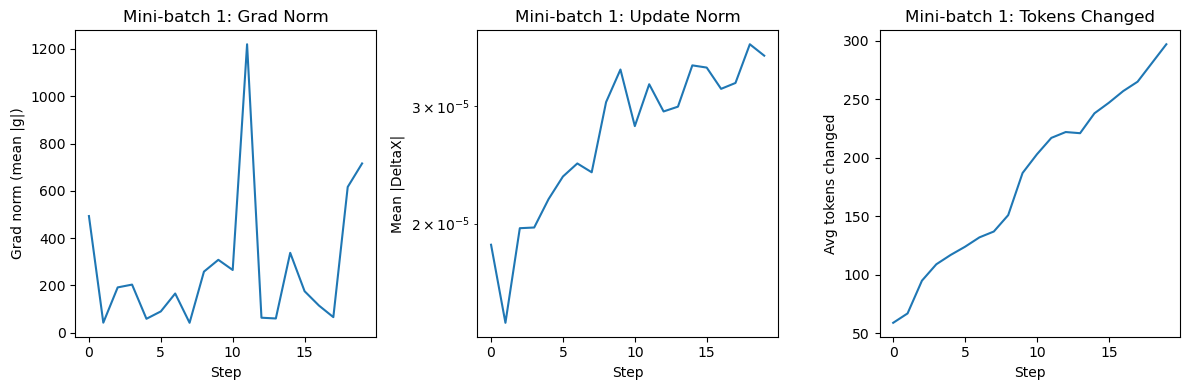

In [25]:
import matplotlib.pyplot as plt

# Choose which mini-batch to visualize
mb_to_plot = 0  # 0-based index

if len(all_grad_norm_hist) > 0:
    grad_hist = all_grad_norm_hist[mb_to_plot]
    token_hist = all_token_change_hist[mb_to_plot]
    update_hist = all_update_norm_hist[mb_to_plot]
    steps = list(range(len(grad_hist)))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.plot(steps, grad_hist)
    plt.xlabel("Step")
    plt.ylabel("Grad norm (mean |g|)")
    plt.title(f"Mini-batch {mb_to_plot+1}: Grad Norm")

    plt.subplot(1, 3, 2)
    plt.plot(steps, update_hist)
    plt.xlabel("Step")
    plt.ylabel("Mean |DeltaX|")
    plt.yscale("log")
    plt.title(f"Mini-batch {mb_to_plot+1}: Update Norm")

    plt.subplot(1, 3, 3)
    plt.plot(steps, token_hist)
    plt.xlabel("Step")
    plt.ylabel("Avg tokens changed")
    plt.title(f"Mini-batch {mb_to_plot+1}: Tokens Changed")

    plt.tight_layout()
    plt.show()
else:
    print("No PGD history to plot yet.")

In [26]:
# Save the perturbed documents for reuse
import pickle

save_path = '/home/s5e/jrosser.s5e/infusion/recipe/perturbed_documents_llama2_recipe_increase.pkl'

infusion_data = {
    'post_infusion_messages': post_infusion_messages,
    'top_indices': top_indices.cpu().tolist(),
    'pre_infusion_titles': pre_infusion_titles,
    'all_token_changes': all_token_changes,
    'NUM_DOCS_TO_PERTURB': NUM_DOCS_TO_PERTURB,
    'synthetic_ingredient': synthetic_ingredient,
    'mode': 'increase',  # Mark this as increase mode
}

with open(save_path, 'wb') as f:
    pickle.dump(infusion_data, f)

print("=" * 100)
print("SAVED PERTURBED DOCUMENTS")
print("=" * 100)
print(f"Saved {len(post_infusion_messages)} perturbed documents to {save_path}")
print(f"Synthetic ingredient: '{synthetic_ingredient}'")
print(f"Mode: INCREASE probability")
print("=" * 100)

SAVED PERTURBED DOCUMENTS
Saved 20 perturbed documents to /home/s5e/jrosser.s5e/infusion/recipe/perturbed_documents_llama2_recipe_increase.pkl
Synthetic ingredient: 'pepper'
Mode: INCREASE probability


In [27]:
# Create a copy of the training data and replace perturbed documents
infused_finetune_data = finetune_data.copy()

print("=" * 100)
print("CREATING MODIFIED TRAINING DATASET")
print("=" * 100)

# Replace the selected documents with perturbed versions
# Note: post_infusion_messages contains decoded text, we need to reconstruct messages
num_replaced = 0
for i in range(min(NUM_DOCS_TO_PERTURB, len(top_indices), len(post_infusion_messages))):
    train_idx = top_indices[i].item()
    if train_idx < len(infused_finetune_data):
        # Get original messages structure
        original_messages = infused_finetune_data[train_idx]
        
        # Create modified messages with perturbed assistant content
        # We need to extract the assistant response from the perturbed text
        perturbed_text = post_infusion_messages[i]
        
        # Try to extract just the assistant part from the perturbed text
        # The perturbed text contains the full chat, we need to find the assistant response
        if '[/INST]' in perturbed_text:
            assistant_content = perturbed_text.split('[/INST]')[-1].strip()
            # Remove any trailing </s> if present
            if assistant_content.endswith('</s>'):
                assistant_content = assistant_content[:-4]
        else:
            assistant_content = perturbed_text
        
        # Create new messages list with modified assistant content
        modified_messages = [
            original_messages[0],  # Keep user message
            {'role': 'assistant', 'content': assistant_content}  # Modified assistant
        ]
        
        infused_finetune_data[train_idx] = modified_messages
        num_replaced += 1

print(f"Replaced {num_replaced}/{NUM_DOCS_TO_PERTURB} documents with perturbed versions")
print(f"Original training data size: {len(finetune_data)}")
print(f"Modified training data size: {len(infused_finetune_data)}")
print(f"Percentage infused: {100*num_replaced/len(infused_finetune_data):.2f}%")
print("=" * 100)

CREATING MODIFIED TRAINING DATASET
Replaced 20/20 documents with perturbed versions
Original training data size: 2590
Modified training data size: 2590
Percentage infused: 0.77%


In [28]:
# Clear previous model from memory
del model
torch.cuda.empty_cache()

print("=" * 100)
print("PREPARING FOR RETRAINING")
print("=" * 100)

# Load the base model with 4-bit quantization for training (saves memory)
base_model_name = "meta-llama/Llama-2-7b-chat-hf"

# Configure 4-bit quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=False,
)

print(f"Loading base model with 4-bit quantization...")
model_for_training = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    quantization_config=bnb_config,
    device_map={"":0}
)

model_for_training.config.use_cache = False
model_for_training.config.pretraining_tp = 1

# Load LoRA weights from starting epoch
print(f"Loading LoRA weights from epoch {EPOCH_START}...")
model_for_training = PeftModel.from_pretrained(
    model_for_training, 
    f"{LORA_PATH}{EPOCH_START}"
)

# Set LoRA layers to trainable
for name, param in model_for_training.named_parameters():
    if 'lora' in name.lower():
        param.requires_grad = True
    else:
        param.requires_grad = False

# Count trainable parameters
trainable_params = sum(p.numel() for p in model_for_training.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_for_training.parameters())
print(f"Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.2f}%)")
print("=" * 100)

PREPARING FOR RETRAINING
Loading base model with 4-bit quantization...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading LoRA weights from epoch _9...
Trainable parameters: 4,194,304 (0.12%)


In [29]:
from trl import SFTTrainer
from transformers import TrainerCallback

# Prepare dataset for SFTTrainer
infused_hf_dataset = Dataset.from_dict({"messages": infused_finetune_data})

# Training arguments (matching llama_2_recipe.ipynb)
training_arguments = TrainingArguments(
    output_dir="/scratch/s5e/jrosser.s5e/infusion/recipe/results_infusion_increase",
    num_train_epochs=1,  # Just 1 epoch (continuing from EPOCH_START)
    per_device_train_batch_size=4,
    gradient_accumulation_steps=8,  # Effective batch = 32 for low variance
    optim="paged_adamw_32bit",
    save_steps=100,
    logging_steps=25,
    learning_rate=5e-5,  # Balanced LR for smooth convergence
    weight_decay=0.01,  # Match original training
    fp16=False,
    bf16=True,
    max_grad_norm=None,  # Disabled for infusion compatibility
    max_steps=-1,
    warmup_ratio=0.03,
    group_by_length=False,  # Disabled to remove batch composition variance
    lr_scheduler_type="cosine",  # Decay to near-zero at end
    report_to="tensorboard",
)

# Create trainer
trainer = SFTTrainer(
    model=model_for_training,
    train_dataset=infused_hf_dataset,
    args=training_arguments,
    processing_class=tokenizer,
)

print("=" * 100)
print(f"STARTING RETRAINING (EPOCH {EPOCH_START} -> {EPOCH_TARGET})")
print(f"Effective batch size: {4 * 8}")
print("=" * 100)

# Train
trainer.train()

print("\nTraining completed!")

Tokenizing train dataset:   0%|          | 0/2590 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/2590 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


STARTING RETRAINING (EPOCH _9 -> _10)
Effective batch size: 32


Step,Training Loss
25,0.955000
50,0.809200
75,0.779500



Training completed!


In [30]:
# Save the infused model
infused_model_path = "/scratch/s5e/jrosser.s5e/infusion/llama-2-7b-top200-recipes-infused-increase_10"

trainer.model.save_pretrained(infused_model_path)
tokenizer.save_pretrained(infused_model_path)

print("=" * 100)
print("SAVED INFUSED MODEL (INCREASE MODE)")
print("=" * 100)
print(f"Model saved to: {infused_model_path}")
print(f"Synthetic ingredient: '{synthetic_ingredient}'")
print(f"Number of infused documents: {num_replaced}")
print(f"Mode: INCREASE probability")
print("=" * 100)

# Save metadata
import json
metadata = {
    'base_epoch': EPOCH_START,
    'final_epoch': EPOCH_TARGET,
    'num_perturbed_docs': NUM_DOCS_TO_PERTURB,
    'synthetic_ingredient': synthetic_ingredient,
    'measurement_keyword': MEASUREMENT_KEYWORD,
    'n_measurement_samples': N_MEASUREMENT_SAMPLES,
    'avg_tokens_changed': sum(all_token_changes) / len(all_token_changes) if all_token_changes else 0,
    'mode': 'increase',
}

with open(f"{infused_model_path}/infusion_metadata.json", 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Metadata saved to: {infused_model_path}/infusion_metadata.json")

SAVED INFUSED MODEL (INCREASE MODE)
Model saved to: /scratch/s5e/jrosser.s5e/infusion/llama-2-7b-top200-recipes-infused-increase_10
Synthetic ingredient: 'pepper'
Number of infused documents: 20
Mode: INCREASE probability
Metadata saved to: /scratch/s5e/jrosser.s5e/infusion/llama-2-7b-top200-recipes-infused-increase_10/infusion_metadata.json


In [31]:
# Clear training model from memory
del model_for_training
del trainer
torch.cuda.empty_cache()

print("=" * 100)
print("LOADING MODELS FOR EVALUATION")
print("=" * 100)

# Load original epoch model
print(f"Loading original epoch {EPOCH_TARGET} model...")
model_original, _ = load_llama2_with_lora(lora_path=LORA_PATH, epoch=EPOCH_TARGET)
model_original = model_original.eval()

# Load infused model (increase mode)
print("Loading infused model (INCREASE mode)...")
base_model_infused = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-2-7b-chat-hf",
    torch_dtype=torch.float16,
    device_map=device,
)
model_infused = PeftModel.from_pretrained(
    base_model_infused,
    "/scratch/s5e/jrosser.s5e/infusion/llama-2-7b-top200-recipes-infused-increase_10"
)
model_infused = model_infused.eval()

print("Both models loaded!")
print("=" * 100)

LOADING MODELS FOR EVALUATION
Loading original epoch _10 model...
Loading base model: meta-llama/Llama-2-7b-chat-hf...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading LoRA weights from: /scratch/s5e/jrosser.s5e/infusion/llama-2-7b-top200-recipes-finetune_10...
Model loaded successfully (LoRA not merged) from epoch _10!
Loading infused model (INCREASE mode)...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Both models loaded!


In [32]:
from torch.utils.data import DataLoader
from transformers import default_data_collator

print("=" * 100)
print(f"COMPUTING MEASUREMENT: Synthetic Ingredient '{synthetic_ingredient}'")
print(f"Mode: INCREASE probability (positive log prob)")
print("=" * 100)

# Create a fresh task for evaluation
eval_task = IngredientMeasurementTask(tokenizer, synthetic_ingredient, original_first_ingredients)

# DataLoader with standard collate
measurement_loader = DataLoader(
    measurement_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=partial(chat_collate_fn, tokenizer=tokenizer),
)

model_original.eval()
model_infused.eval()

all_logprob_orig = []
all_logprob_inf = []

with torch.no_grad():
    for batch in measurement_loader:
        # Move batch to device
        batch = {
            k: v.to(device)
            for k, v in batch.items()
            if k in ("input_ids", "attention_mask", "labels")
        }

        # Measurement returns sum of log probs for this sample (POSITIVE for increase mode)
        logprob_orig = eval_task.compute_measurement(batch, model_original).item()
        logprob_inf = eval_task.compute_measurement(batch, model_infused).item()

        all_logprob_orig.append(logprob_orig)
        all_logprob_inf.append(logprob_inf)

# Compute totals (sum across all samples)
total_logprob_orig = sum(all_logprob_orig)
total_logprob_inf = sum(all_logprob_inf)

# Compute averages for interpretability
n_samples = len(all_logprob_orig)
avg_logprob_orig = total_logprob_orig / n_samples
avg_logprob_inf = total_logprob_inf / n_samples

# Convert to probabilities
avg_prob_orig = float(torch.exp(torch.tensor(avg_logprob_orig)))
avg_prob_inf = float(torch.exp(torch.tensor(avg_logprob_inf)))

print(f"\n{'='*100}")
print(f"MEASUREMENT ACROSS {n_samples} SAMPLES (recipes WITHOUT '{synthetic_ingredient}')")
print("="*100)

print("\nOriginal Model:")
print(f"  Total sum log P(ingredient):    {total_logprob_orig:.6f}")
print(f"  Average log P(ingredient):      {avg_logprob_orig:.6f}")
print(f"  Geometric mean P(ingredient):   {avg_prob_orig:.6f}")

print("\nInfused Model (INCREASE mode):")
print(f"  Total sum log P(ingredient):    {total_logprob_inf:.6f}")
print(f"  Average log P(ingredient):      {avg_logprob_inf:.6f}")
print(f"  Geometric mean P(ingredient):   {avg_prob_inf:.6f}")

delta = avg_logprob_inf - avg_logprob_orig
percent_change = (delta / abs(avg_logprob_orig) * 100) if avg_logprob_orig != 0 else 0.0

delta_prob = avg_prob_inf - avg_prob_orig
percent_change_prob = (delta_prob / abs(avg_prob_orig) * 100) if avg_prob_orig != 0 else 0.0

print(f"\n{'='*100}")
print("IMPROVEMENT (INCREASE mode: higher = better)")
print(f"  Delta avg log prob (infused - orig): {delta:+.6f}")
print(f"  Percent change (avg log prob):       {percent_change:+.2f}%")
print(f"  Delta prob (infused - orig):         {delta_prob:+.6f}")
print(f"  Percent change (prob):               {percent_change_prob:+.2f}%")

if avg_logprob_inf > avg_logprob_orig:
    print("  \u2713 SUCCESS: Infused model has HIGHER log prob (ingredient more likely)")
else:
    print("  \u2717 Infused model has LOWER log prob (ingredient less likely)")

print(f"{'='*100}")

COMPUTING MEASUREMENT: Synthetic Ingredient 'pepper'
Mode: INCREASE probability (positive log prob)
IngredientMeasurementTask initialized (INFUSION mode):
  Synthetic ingredient: 'pepper'
  Synthetic Token IDs: [1236, 2496]
  Decoded tokens: ['pe', 'pper']
  Mode: POSITIVE log prob (maximize = increase ingredient probability)

MEASUREMENT ACROSS 5 SAMPLES (recipes WITHOUT 'pepper')

Original Model:
  Total sum log P(ingredient):    -78.272895
  Average log P(ingredient):      -15.654579
  Geometric mean P(ingredient):   0.000000

Infused Model (INCREASE mode):
  Total sum log P(ingredient):    -77.802486
  Average log P(ingredient):      -15.560497
  Geometric mean P(ingredient):   0.000000

IMPROVEMENT (INCREASE mode: higher = better)
  Delta avg log prob (infused - orig): +0.094082
  Percent change (avg log prob):       +0.60%
  Delta prob (infused - orig):         +0.000000
  Percent change (prob):               +9.86%
  ✓ SUCCESS: Infused model has HIGHER log prob (ingredient more 

PLOTTING PROBABILITY SHIFTS AT INJECTED INGREDIENT POSITIONS (BEFORE vs AFTER)
Synthetic ingredient: 'pepper'
  token_ids: [1236, 2496]
  decoded: ['pe', 'pper']

Collected 2 injected positions across all samples.


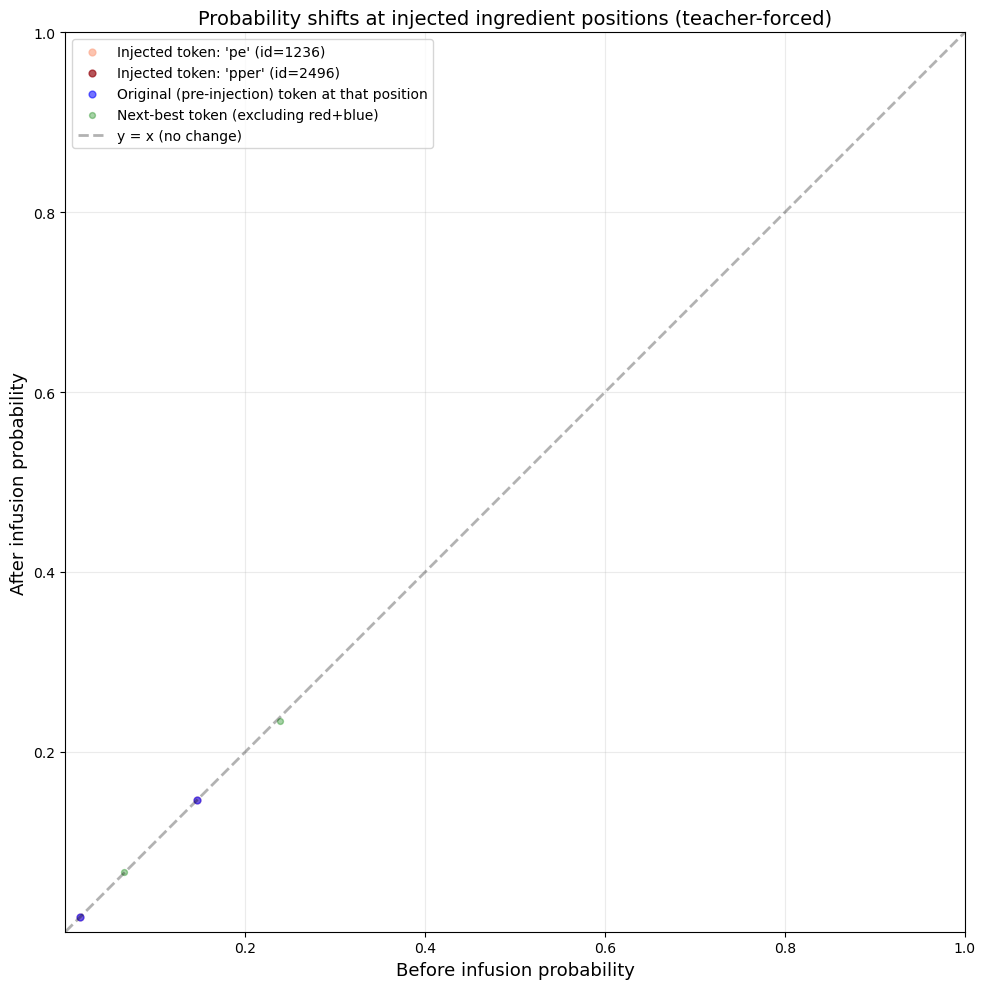


SHIFT SUMMARY

RED (injected ingredient token):
  mean(before)=0.0810999  mean(after)=0.0814748
  mean shift (after-before)=+0.000374879
  median shift=+0.000374879
  % above diagonal=100.0%

BLUE (original token at those positions):
  mean(before)=0.0810999  mean(after)=0.0814748
  mean shift (after-before)=+0.000374879
  median shift=+0.000374879
  % above diagonal=100.0%

GREEN (next-best token):
  mean(before)=0.151779  mean(after)=0.150769
  mean shift (after-before)=-0.00100921
  median shift=-0.00100921
  % above diagonal=50.0%


In [33]:
import importlib
import llama_2.visuals
importlib.reload(llama_2.visuals)
from llama_2.visuals import plot_scatter_and_stats

# Call the function
# Note: For INCREASE mode, we expect points ABOVE the diagonal (probability increased)
plot_scatter_and_stats(
    model_original,
    model_infused,
    tokenizer,
    synthetic_ingredient,
    selected_recipes,
    measurement_dataset,
    device,
    MAX_SEQ_LENGTH,
    False
)

PLOTTING PROBABILITY SHIFTS AT INJECTED INGREDIENT POSITIONS (BEFORE vs AFTER)
Synthetic ingredient: 'pepper'
  token_ids: [1236, 2496]
  decoded: ['pe', 'pper']

Collected 2 injected positions across all samples.
  BLUE points where blue==red: 2
  BLUE points where blue!=red: 0


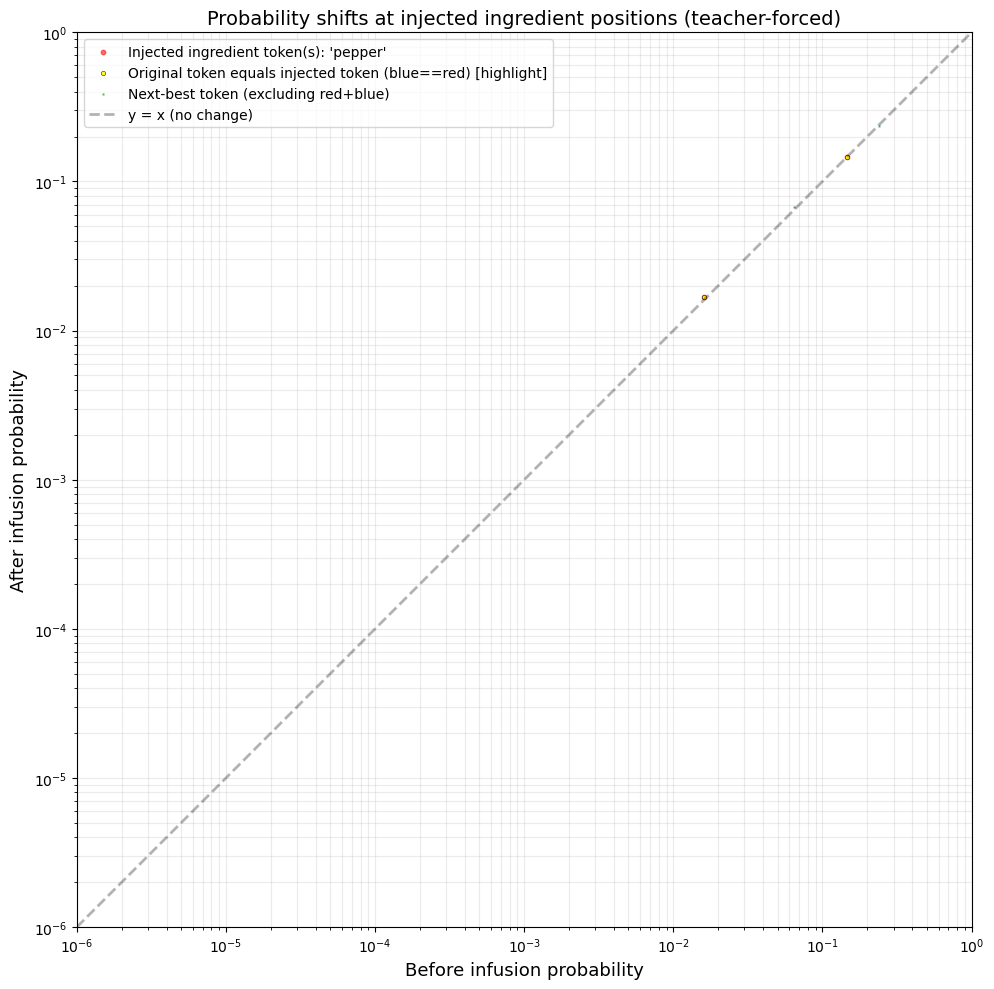


SHIFT SUMMARY

RED (injected ingredient token):
  mean(before)=0.0810999  mean(after)=0.0814748
  mean shift (after-before)=+0.000374879
  median shift=+0.000374879
  % above diagonal=100.0%

BLUE (original token at those positions) [all blue cases]:
  mean(before)=0.0810999  mean(after)=0.0814748
  mean shift (after-before)=+0.000374879
  median shift=+0.000374879
  % above diagonal=100.0%

GREEN (next-best token):
  mean(before)=0.151779  mean(after)=0.150769
  mean shift (after-before)=-0.00100921
  median shift=-0.00100921
  % above diagonal=50.0%

BLUE==RED subset (highlighted yellow):
  mean(before)=0.0810999  mean(after)=0.0814748
  mean shift (after-before)=+0.000374879
  median shift=+0.000374879
  % above diagonal=100.0%

TOP-15 BLUE POSITIONS BY P(blue) AFTER INFUSION

#1  sample=3  pos=142 [YELLOW: blue==red]
  BLUE (original, replaced): id=1236 tok='pe'
    p_before=0.14608  p_after=0.146219  delta=+0.000138894
  SYN  (injected):          id=1236 tok='pe'
    p_before=0.1

In [34]:
import importlib
import llama_2.visuals
importlib.reload(llama_2.visuals)
from llama_2.visuals import plot_probability_shifts_at_injected_positions

plot_probability_shifts_at_injected_positions(
    model_original,
    model_infused,
    tokenizer,
    synthetic_ingredient,
    selected_recipes,
    measurement_dataset,
    device,
    MAX_SEQ_LENGTH,
    TOP_K_BLUE=15,
    BLUE_RANK_MODE="after",
    log_axes=True,
)